In [1]:
import pandas as pd
import joblib

# Load clean dataset
df = pd.read_csv("../data/news_dataset_clean.csv")

# Remove empty rows again (safety)
df = df.dropna(subset=["clean_text"])
df = df[df["clean_text"].str.strip() != ""]

X = df["clean_text"]
y = df["label"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Load vectorizer
vectorizer = joblib.load("../models/tfidf_vectorizer.pkl")

X_train_tfidf = vectorizer.transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [2]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report (Naive Bayes):\n", classification_report(y_test, y_pred_nb))


Naive Bayes Accuracy: 0.9455613282132369

Classification Report (Naive Bayes):
               precision    recall  f1-score   support

           0       0.95      0.94      0.95      4551
           1       0.94      0.95      0.94      4303

    accuracy                           0.95      8854
   macro avg       0.95      0.95      0.95      8854
weighted avg       0.95      0.95      0.95      8854



In [3]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report (Logistic Regression):\n", classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.987576236729162

Classification Report (Logistic Regression):
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      4551
           1       0.99      0.99      0.99      4303

    accuracy                           0.99      8854
   macro avg       0.99      0.99      0.99      8854
weighted avg       0.99      0.99      0.99      8854



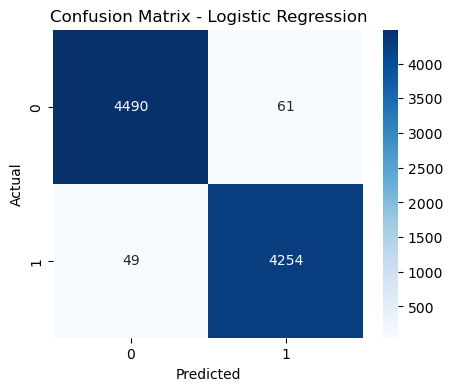

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


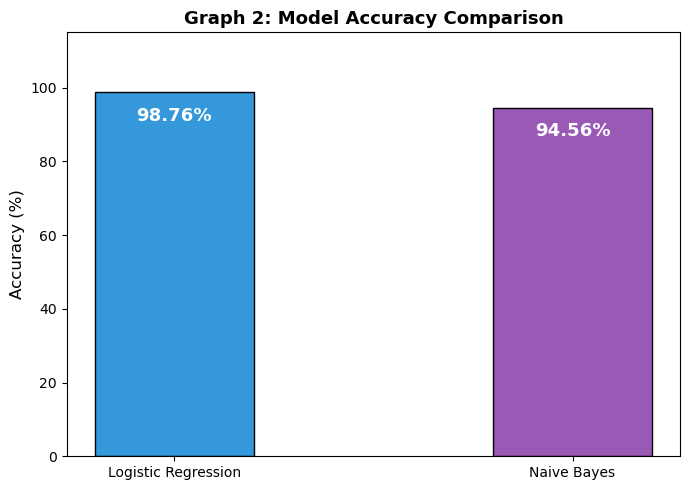

LR: 98.76% | NB: 94.56%


In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
%matplotlib inline

acc_lr = accuracy_score(y_test, y_pred_lr) * 100
acc_nb = accuracy_score(y_test, y_pred_nb) * 100

plt.figure(figsize=(7, 5))
models     = ['Logistic Regression', 'Naive Bayes']
accuracies = [acc_lr, acc_nb]
colors     = ['#3498db', '#9b59b6']

bars = plt.bar(models, accuracies, color=colors, edgecolor='black', width=0.4)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() - 4, f'{acc:.2f}%',
             ha='center', va='top', fontsize=13,
             fontweight='bold', color='white')

plt.title('Graph 2: Model Accuracy Comparison', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 115)
plt.tight_layout()
plt.savefig('../data/graph2_accuracy_comparison.png', dpi=150)
plt.show()
print(f'LR: {acc_lr:.2f}% | NB: {acc_nb:.2f}%')



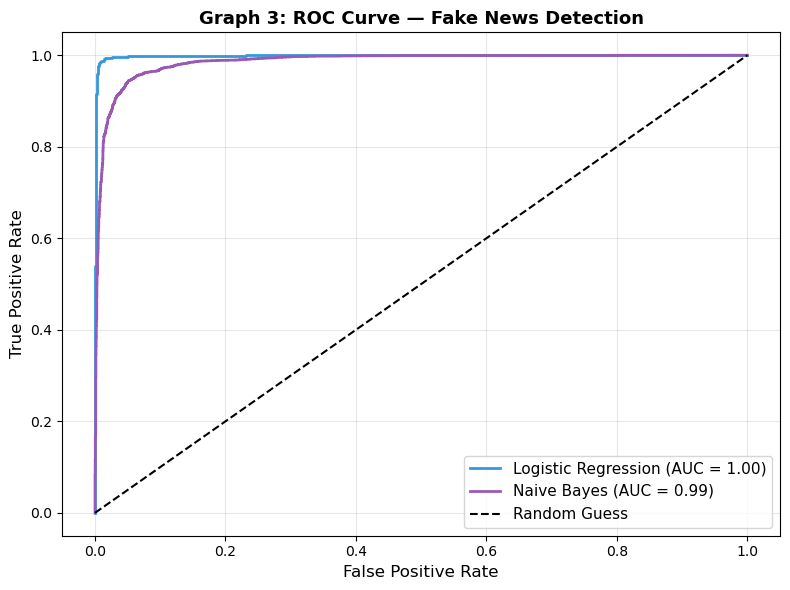

LR AUC: 1.00 | NB AUC: 0.99


In [6]:
from sklearn.metrics import roc_curve, auc

y_prob_lr = lr_model.predict_proba(X_test_tfidf)[:, 1]
y_prob_nb = nb_model.predict_proba(X_test_tfidf)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
auc_lr = auc(fpr_lr, tpr_lr)
auc_nb = auc(fpr_nb, tpr_nb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='#3498db', lw=2,
         label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot(fpr_nb, tpr_nb, color='#9b59b6', lw=2,
         label=f'Naive Bayes (AUC = {auc_nb:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Guess')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Graph 3: ROC Curve — Fake News Detection',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/graph3_roc_curve.png', dpi=150)
plt.show()
print(f'LR AUC: {auc_lr:.2f} | NB AUC: {auc_nb:.2f}')



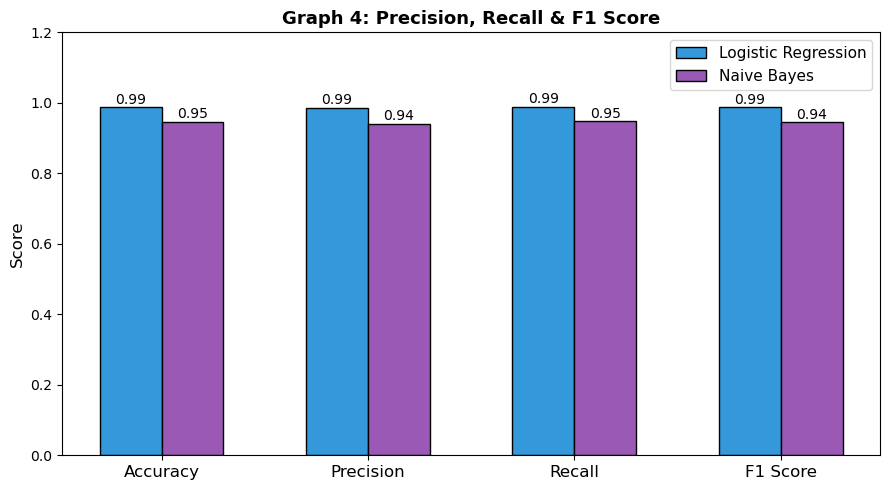

In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

metrics  = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
lr_scores = [
    accuracy_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr)
]
nb_scores = [
    accuracy_score(y_test, y_pred_nb),
    precision_score(y_test, y_pred_nb),
    recall_score(y_test, y_pred_nb),
    f1_score(y_test, y_pred_nb)
]

x = np.arange(len(metrics))
width = 0.3

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, lr_scores, width, label='Logistic Regression',
        color='#3498db', edgecolor='black')
plt.bar(x + width/2, nb_scores, width, label='Naive Bayes',
        color='#9b59b6', edgecolor='black')

for i, (lr, nb) in enumerate(zip(lr_scores, nb_scores)):
    plt.text(i - width/2, lr + 0.01, f'{lr:.2f}', ha='center', fontsize=10)
    plt.text(i + width/2, nb + 0.01, f'{nb:.2f}', ha='center', fontsize=10)

plt.xticks(x, metrics, fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0, 1.2)
plt.title('Graph 4: Precision, Recall & F1 Score', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../data/graph4_precision_recall_f1.png', dpi=150)
plt.show()


In [8]:
print('=' * 50)
print('   FAKE NEWS DETECTION — FINAL RESULTS')
print('=' * 50)
print(f'  Logistic Regression Accuracy : {acc_lr:.2f}%')
print(f'  Naive Bayes Accuracy         : {acc_nb:.2f}%')
best = 'Logistic Regression' if acc_lr >= acc_nb else 'Naive Bayes'
print(f'  Best Model                   : {best}')
print('=' * 50)



   FAKE NEWS DETECTION — FINAL RESULTS
  Logistic Regression Accuracy : 98.76%
  Naive Bayes Accuracy         : 94.56%
  Best Model                   : Logistic Regression


In [9]:
joblib.dump(lr_model, "../models/fake_news_model.pkl")
print("Best model saved successfully!")


Best model saved successfully!
